# ACPP3 HW02

Author: 인공지능학과 202524225 정민규

GitHub: https://github.com/Gnaroshi/ACPP3_HW02


In [2]:
# 사용할 라이브러리 모두 불러오기

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
plt.style.use("default")


## 데이터 개요


In [5]:
# 데이터 불러오기
df = pd.read_csv("titanic.csv")
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# 데이터 크기와 기본 정보 확인
print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())

데이터 크기: (891, 12)
컬럼 목록:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [ ]:
# 데이터 타입과 결측치 확입
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
# 데이터 통계 요약
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [12]:
# 결측치 비율 확인

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio(%)": (df.isna().mean() * 100).round(2)
}).sort_values("missing_ratio(%)", ascending=False)

print(missing_summary)

             missing_count  missing_ratio(%)
Cabin                  687             77.10
Age                    177             19.87
Embarked                 2              0.22
PassengerId              0              0.00
Survived                 0              0.00
Pclass                   0              0.00
Name                     0              0.00
Sex                      0              0.00
SibSp                    0              0.00
Parch                    0              0.00
Ticket                   0              0.00
Fare                     0              0.00


In [ ]:
# 타깃 변수 분포 확인
print(df["Survived"].value_counts())
print()
print(df["Survived"].value_counts(normalize=True))

Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


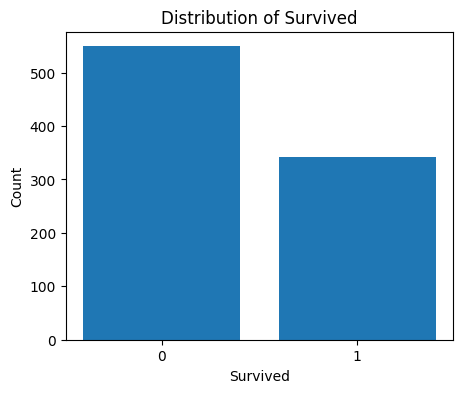

In [14]:
# 타깃 변수 시각화
target_counts = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Distribution of Survived")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [16]:
# 수치형 변수와 범주형 변수 구분
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("수치형 컬럼:")
print(numeric_cols)

print("범주형 컬럼:")
print(categorical_cols)

수치형 컬럼:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
범주형 컬럼:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [17]:
# 데이터 개요 요약표
summary_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_ratio(%)": (df.isna().mean() * 100).round(2).values,
    "n_unique": [df[col].nunique(dropna=False) for col in df.columns],
})

summary_df

,column,dtype,missing_count,missing_ratio(%),n_unique
0,PassengerId,int64,0,0.00,891
1,Survived,int64,0,0.00,2
2,Pclass,int64,0,0.00,3
3,Name,str,0,0.00,891
4,Sex,str,0,0.00,2
5,Age,float64,177,19.87,89
6,SibSp,int64,0,0.00,7
7,Parch,int64,0,0.00,7
8,Ticket,str,0,0.00,681
9,Fare,float64,0,0.00,248


## 전처리 구조

In [18]:
target_col = "Survived"

feature_cols = [
    "Pclass", "Age", "SibSp", "Parch", "Fare",
    "Sex", "Embarked"
]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (891, 7)
y shape: (891,)


,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
0,3,22.0,1,0,7.2500,male,S
1,1,38.0,1,0,71.2833,female,C
2,3,26.0,0,0,7.9250,female,S
3,1,35.0,1,0,53.1000,female,S
4,3,35.0,0,0,8.0500,male,S


In [19]:
# 수치형 / 범주형 변수 분리
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)

수치형 변수: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
범주형 변수: ['Sex', 'Embarked']


In [24]:
# 사용할 수치형 변수의 min, max, mean, median, std 확인
baseline_numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

baseline_range_summary = pd.DataFrame({
    "min": df[baseline_numeric_features].min(),
    "max": df[baseline_numeric_features].max(),
    "mean": df[baseline_numeric_features].mean(),
    "std": df[baseline_numeric_features].std(),
})

baseline_range_summary["range"] = baseline_range_summary["max"] - baseline_range_summary["min"]
baseline_range_summary.sort_values("range", ascending=False)


,min,max,mean,std,range
Fare,0.00,512.3292,32.204208,49.693429,512.3292
Age,0.42,80.0000,29.699118,14.526497,79.5800
SibSp,0.00,8.0000,0.523008,1.102743,8.0000
Parch,0.00,6.0000,0.381594,0.806057,6.0000
Pclass,1.00,3.0000,2.308642,0.836071,2.0000


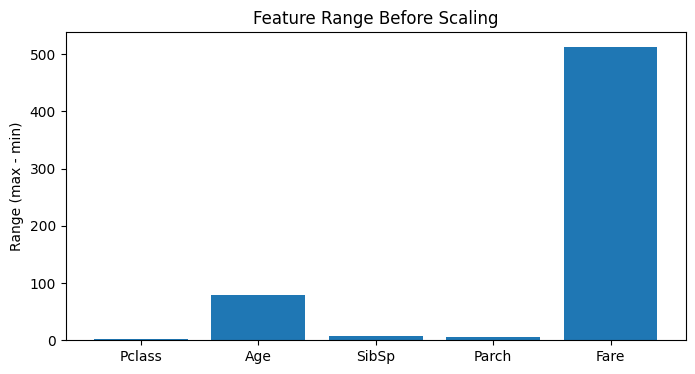

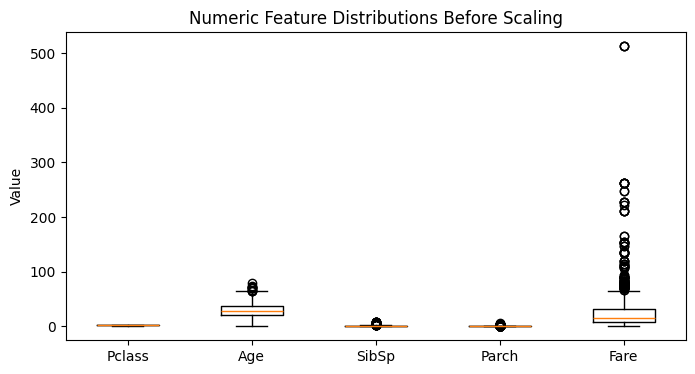

In [27]:
# 시각화로 수치형 변수의 범위 비교하기
mins = baseline_range_summary["min"].values
maxs = baseline_range_summary["max"].values
ranges = baseline_range_summary["range"].values
labels = baseline_range_summary.index.tolist()

plt.figure(figsize=(8, 4))
plt.bar(labels, ranges)
plt.title("Feature Range Before Scaling")
plt.ylabel("Range (max - min)")
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot([df[col].dropna() for col in baseline_numeric_features], labels=baseline_numeric_features)
plt.title("Numeric Feature Distributions Before Scaling")
plt.ylabel("Value")
plt.show()

In [28]:
# StandardScaler로 수치형 변수 스케일링했을 때 비교
from sklearn.preprocessing import StandardScaler

scaled_values = StandardScaler().fit_transform(df[baseline_numeric_features].dropna())
scaled_df = pd.DataFrame(scaled_values, columns=baseline_numeric_features)

scaled_summary = pd.DataFrame({
    "min": scaled_df.min(),
    "max": scaled_df.max(),
    "mean": scaled_df.mean(),
    "std": scaled_df.std(),
})
scaled_summary["range"] = scaled_summary["max"] - scaled_summary["min"]
scaled_summary

,min,max,mean,std,range
Pclass,-1.476364,0.911232,-5.473368e-17,1.000701,2.387596
Age,-2.016979,3.465126,2.338621e-16,1.000701,5.482105
SibSp,-0.551703,4.829663,-4.975789e-18,1.000701,5.381366
Parch,-0.505895,6.530646,-7.214895e-17,1.000701,7.036542
Fare,-0.656076,9.032109,-5.970947e-17,1.000701,9.688184


In [29]:
before_after_compare = pd.DataFrame({
    "before_min": df[baseline_numeric_features].min(),
    "before_max": df[baseline_numeric_features].max(),
    "before_std": df[baseline_numeric_features].std(),
})

scaled_values = StandardScaler().fit_transform(df[baseline_numeric_features].dropna())
scaled_df = pd.DataFrame(scaled_values, columns=baseline_numeric_features)

before_after_compare["after_min"] = scaled_df.min().values
before_after_compare["after_max"] = scaled_df.max().values
before_after_compare["after_std"] = scaled_df.std().values

before_after_compare

,before_min,before_max,before_std,after_min,after_max,after_std
Pclass,1.00,3.0000,0.836071,-1.476364,0.911232,1.000701
Age,0.42,80.0000,14.526497,-2.016979,3.465126,1.000701
SibSp,0.00,8.0000,1.102743,-0.551703,4.829663,1.000701
Parch,0.00,6.0000,0.806057,-0.505895,6.530646,1.000701
Fare,0.00,512.3292,49.693429,-0.656076,9.032109,1.000701


In [20]:
# train / test split
# 전처리를 전체 데이터에 먼저 fitting하면 안되므로 split을 먼저 수행
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (712, 7)
X_test : (179, 7)
y_train distribution:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
y_test distribution:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [21]:
# 수치형 전처리 파이프라인
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

In [30]:
# 범주형 전처리 파이프라인
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

categorical_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation.

In [31]:
# ColumnTransformer로 수치형/범주형 전처리 통합하기
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [34]:
# 전처리를 했을 때 결과학인
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("원본 X_train shape:", X_train.shape)
print("변환 후 X_train shape:", X_train_transformed.shape)
print("원본 X_test shape:", X_test.shape)
print("변환 후 X_test shape:", X_test_transformed.shape)

feature_names = preprocessor.get_feature_names_out()
print("전처리 후 feature 개수:", len(feature_names))
print(feature_names)


원본 X_train shape: (712, 7)
변환 후 X_train shape: (712, 10)
원본 X_test shape: (179, 7)
변환 후 X_test shape: (179, 10)
전처리 후 feature 개수: 10
['num__Pclass' 'num__Age' 'num__SibSp' 'num__Parch' 'num__Fare'
 'cat__Sex_female' 'cat__Sex_male' 'cat__Embarked_C' 'cat__Embarked_Q'
 'cat__Embarked_S']


In [35]:
# Pipeline으로 모델까지 연결하는 기본 구조 확인
from sklearn.svm import SVC

baseline_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SVC())
])

baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [36]:
# Scaler만 바꿔서 재사용할 수 있도록 함수화
from sklearn.preprocessing import MinMaxScaler

def make_preprocessor(scaler="standard"):
    if scaler == "standard":
        scaler_obj = StandardScaler()
    elif scaler == "minmax":
        scaler_obj = MinMaxScaler()
    elif scaler is None:
        scaler_obj = None
    else:
        raise ValueError("scaler는 'standard', 'minmax', None 중 하나여야 합니다.")

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scaler_obj is not None:
        numeric_steps.append(("scaler", scaler_obj))

    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    return preprocessor

## 성능 비교


In [38]:
# 평가 함수 정의
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        score = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline, "decision_function"):
        score = pipeline.decision_function(X_test)
    else:
        score = None

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, score) if score is not None else np.nan,
    }

    return result, pred


In [39]:
# 실험 1: SVM (No Scaling)
svm_no_scaling = Pipeline(steps=[
    ("preprocess", make_preprocessor(scaler=None)),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

res_svm_no_scaling, pred_svm_no_scaling = evaluate_model(
    "SVM (No Scaling)",
    svm_no_scaling,
    X_train, X_test, y_train, y_test
)

res_svm_no_scaling


{'model': 'SVM (No Scaling)',
 'accuracy': 0.6201117318435754,
 'precision': 0.5161290322580645,
 'recall': 0.2318840579710145,
 'f1': 0.32,
 'roc_auc': 0.7007246376811594}

In [40]:
# 실험 2: StandardScaler + SVM
svm_standard = Pipeline(steps=[
    ("preprocess", make_preprocessor(scaler="standard")),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

res_svm_standard, pred_svm_standard = evaluate_model(
    "StandardScaler + SVM",
    svm_standard,
    X_train, X_test, y_train, y_test
)

res_svm_standard

{'model': 'StandardScaler + SVM',
 'accuracy': 0.8156424581005587,
 'precision': 0.8214285714285714,
 'recall': 0.6666666666666666,
 'f1': 0.736,
 'roc_auc': 0.8404479578392622}

In [41]:
# 실험 3: StandardScaler + KNN
knn_standard = Pipeline(steps=[
    ("preprocess", make_preprocessor(scaler="standard")),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

res_knn_standard, pred_knn_standard = evaluate_model(
    "StandardScaler + KNN",
    knn_standard,
    X_train, X_test, y_train, y_test
)

res_knn_standard

{'model': 'StandardScaler + KNN',
 'accuracy': 0.8156424581005587,
 'precision': 0.8,
 'recall': 0.6956521739130435,
 'f1': 0.7441860465116279,
 'roc_auc': 0.8488142292490118}

In [42]:
# 실험 4: MinMaxScaler + SVM
svm_minmax = Pipeline(steps=[
    ("preprocess", make_preprocessor(scaler="minmax")),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

res_svm_minmax, pred_svm_minmax = evaluate_model(
    "MinMaxScaler + SVM",
    svm_minmax,
    X_train, X_test, y_train, y_test
)

res_svm_minmax

{'model': 'MinMaxScaler + SVM',
 'accuracy': 0.7932960893854749,
 'precision': 0.8636363636363636,
 'recall': 0.5507246376811594,
 'f1': 0.672566371681416,
 'roc_auc': 0.852042160737813}

In [47]:
# 실험 5: MinMaxScaler + KNN
knn_minmax = Pipeline(steps=[
    ("preprocess", make_preprocessor(scaler="minmax")),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

res_knn_minmax, pred_knn_minmax = evaluate_model(
    "MinMaxScaler + KNN",
    knn_minmax,
    X_train, X_test, y_train, y_test
)

res_knn_minmax

{'model': 'MinMaxScaler + KNN',
 'accuracy': 0.8100558659217877,
 'precision': 0.8181818181818182,
 'recall': 0.6521739130434783,
 'f1': 0.7258064516129032,
 'roc_auc': 0.8429512516469039}

In [48]:
# 실험 결과 비교
results = pd.DataFrame([
    res_svm_no_scaling,
    res_svm_standard,
    res_knn_standard,
    res_svm_minmax,
    res_knn_minmax
]).sort_values(by="f1", ascending=False)

print("original results:")
print(results)

results_rounded = results.copy()
for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    results_rounded[col] = results_rounded[col].round(4)

print("rounded results:")
print(results_rounded)

pred_dict = {
    "SVM (No Scaling)": pred_svm_no_scaling,
    "StandardScaler + SVM": pred_svm_standard,
    "StandardScaler + KNN": pred_knn_standard,
    "MinMaxScaler + SVM": pred_svm_minmax,
    "MinMaxScaler + KNN": pred_knn_minmax
}

for name, pred in pred_dict.items():
    print(f"\\n===== {name} =====")
    print(classification_report(y_test, pred, digits=4))

original results:
                  model  accuracy  precision    recall        f1   roc_auc
2  StandardScaler + KNN  0.815642   0.800000  0.695652  0.744186  0.848814
1  StandardScaler + SVM  0.815642   0.821429  0.666667  0.736000  0.840448
4    MinMaxScaler + KNN  0.810056   0.818182  0.652174  0.725806  0.842951
3    MinMaxScaler + SVM  0.793296   0.863636  0.550725  0.672566  0.852042
0      SVM (No Scaling)  0.620112   0.516129  0.231884  0.320000  0.700725
rounded results:
                  model  accuracy  precision  recall      f1  roc_auc
2  StandardScaler + KNN    0.8156     0.8000  0.6957  0.7442   0.8488
1  StandardScaler + SVM    0.8156     0.8214  0.6667  0.7360   0.8404
4    MinMaxScaler + KNN    0.8101     0.8182  0.6522  0.7258   0.8430
3    MinMaxScaler + SVM    0.7933     0.8636  0.5507  0.6726   0.8520
0      SVM (No Scaling)    0.6201     0.5161  0.2319  0.3200   0.7007
\n===== SVM (No Scaling) =====
              precision    recall  f1-score   support

         

\n===== SVM (No Scaling) =====
[[95 15]
 [53 16]]
\n===== StandardScaler + SVM =====
[[100  10]
 [ 23  46]]
\n===== StandardScaler + KNN =====
[[98 12]
 [21 48]]
\n===== MinMaxScaler + SVM =====
[[104   6]
 [ 31  38]]
\n===== MinMaxScaler + KNN =====
[[100  10]
 [ 24  45]]


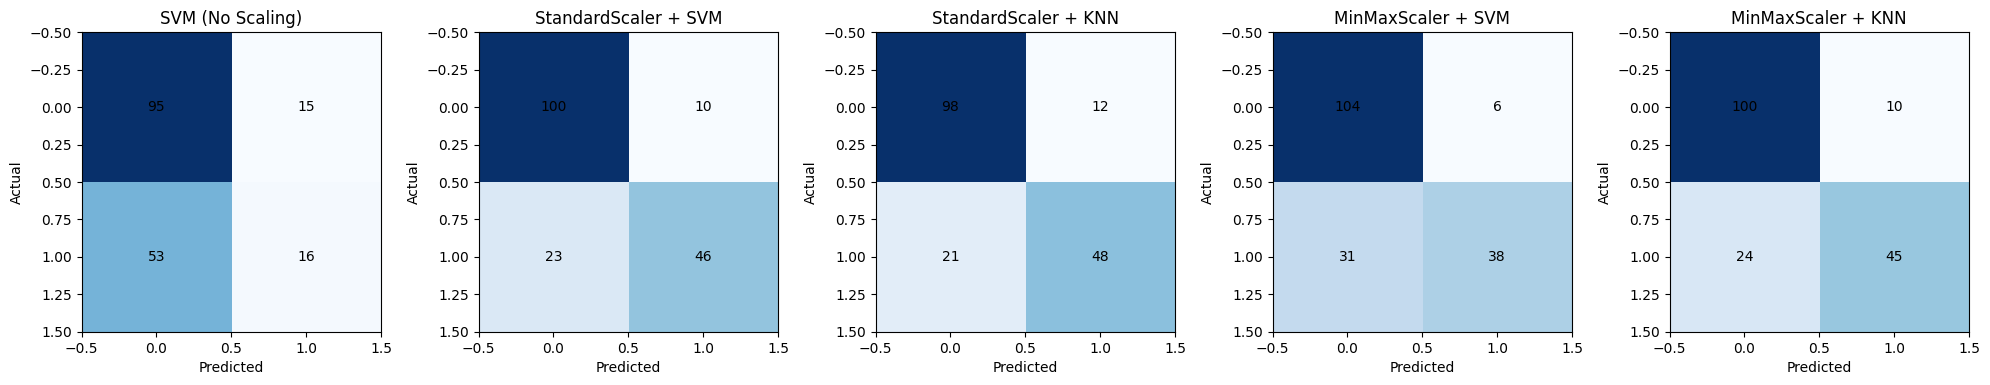

In [52]:
# confusion matrix 비교
cm_dict = {
    "SVM (No Scaling)": confusion_matrix(y_test, pred_svm_no_scaling),
    "StandardScaler + SVM": confusion_matrix(y_test, pred_svm_standard),
    "StandardScaler + KNN": confusion_matrix(y_test, pred_knn_standard),
    "MinMaxScaler + SVM": confusion_matrix(y_test, pred_svm_minmax),
    "MinMaxScaler + KNN": confusion_matrix(y_test, pred_knn_minmax),
}

for name, cm in cm_dict.items():
    print(f"\\n===== {name} =====")
    print(cm)
    
cms = [
    ("SVM (No Scaling)", confusion_matrix(y_test, pred_svm_no_scaling)),
    ("StandardScaler + SVM", confusion_matrix(y_test, pred_svm_standard)),
    ("StandardScaler + KNN", confusion_matrix(y_test, pred_knn_standard)),
    ("MinMaxScaler + SVM", confusion_matrix(y_test, pred_svm_minmax)),
    ("MinMaxScaler + KNN", confusion_matrix(y_test, pred_knn_minmax)),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (title, cm) in zip(axes, cms):
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 전처리 영향

In [53]:
# SVM 전처리 비교
preprocess_impact_df = pd.DataFrame([
    res_svm_no_scaling,
    res_svm_standard,
    res_svm_minmax,
])

preprocess_impact_df = preprocess_impact_df[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]]
preprocess_impact_df = preprocess_impact_df.round(4)

preprocess_impact_df

,model,accuracy,precision,recall,f1,roc_auc
0,SVM (No Scaling),0.6201,0.5161,0.2319,0.3200,0.7007
1,StandardScaler + SVM,0.8156,0.8214,0.6667,0.7360,0.8404
2,MinMaxScaler + SVM,0.7933,0.8636,0.5507,0.6726,0.8520


In [ ]:
# SVM 전처리 비교 - 차이 계산
svm_compare_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "SVM (No Scaling)": [
        res_svm_no_scaling["accuracy"],
        res_svm_no_scaling["precision"],
        res_svm_no_scaling["recall"],
        res_svm_no_scaling["f1"],
        res_svm_no_scaling["roc_auc"],
    ],
    "StandardScaler + SVM": [
        res_svm_standard["accuracy"],
        res_svm_standard["precision"],
        res_svm_standard["recall"],
        res_svm_standard["f1"],
        res_svm_standard["roc_auc"],
    ],
        "MinMaxScaler + SVM": [
            res_svm_minmax["accuracy"],
            res_svm_minmax["precision"],
            res_svm_minmax["recall"],
            res_svm_minmax["f1"],
            res_svm_minmax["roc_auc"],
        ],
})

svm_compare_df["difference_standard"] = svm_compare_df["StandardScaler + SVM"] - svm_compare_df["SVM (No Scaling)"]
svm_compare_df["difference_minmax"] = svm_compare_df["MinMaxScaler + SVM"] - svm_compare_df["SVM (No Scaling)"]
svm_compare_df = svm_compare_df[["metric", "SVM (No Scaling)", "StandardScaler + SVM", "MinMaxScaler + SVM", "difference_standard", "difference_minmax"]]
svm_compare_df = svm_compare_df.round(4)

svm_compare_df

,metric,SVM (No Scaling),StandardScaler + SVM,MinMaxScaler + SVM,difference_standard,difference_minmax
0,accuracy,0.6201,0.8156,0.7933,0.1955,0.1732
1,precision,0.5161,0.8214,0.8636,0.3053,0.3475
2,recall,0.2319,0.6667,0.5507,0.4348,0.3188
3,f1,0.3200,0.7360,0.6726,0.4160,0.3526
4,roc_auc,0.7007,0.8404,0.8520,0.1397,0.1513


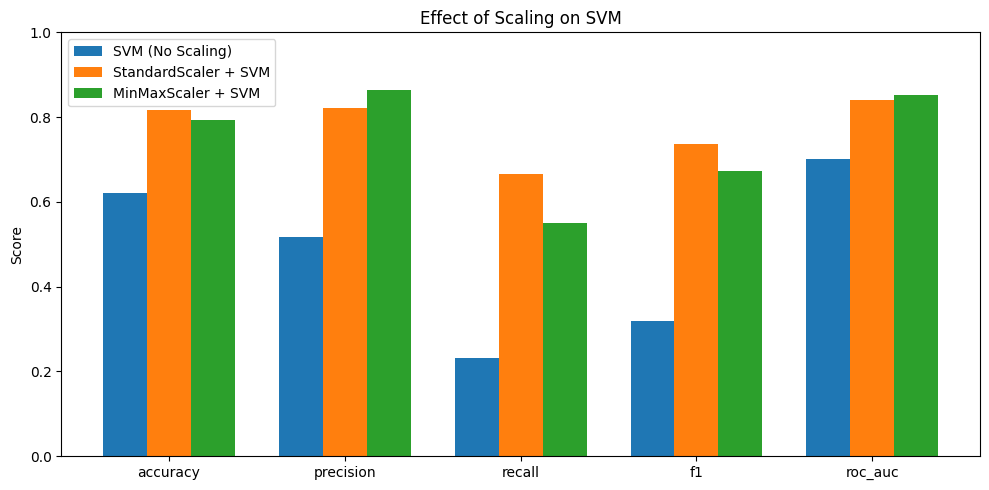

In [57]:
# SVM 전처리 비교 - 시각화
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

no_scaling_scores = [res_svm_no_scaling[m] for m in metrics]
standard_scores = [res_svm_standard[m] for m in metrics]
minmax_scores = [res_svm_minmax[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, no_scaling_scores, width=width, label="SVM (No Scaling)")
plt.bar(x, standard_scores, width=width, label="StandardScaler + SVM")
plt.bar(x + width, minmax_scores, width=width, label="MinMaxScaler + SVM")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Effect of Scaling on SVM")
plt.legend()
plt.tight_layout()
plt.show()

## 모델 해설

In [62]:
# StandardScaler + KNN, MinMaxScaler + KNN 비교
model_compare_df = pd.DataFrame([
    res_svm_standard,
    res_knn_standard,
])

model_compare_df = model_compare_df[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]]
model_compare_df = model_compare_df.round(4)

model_compare_df

,model,accuracy,precision,recall,f1,roc_auc
0,StandardScaler + SVM,0.8156,0.8214,0.6667,0.7360,0.8404
1,StandardScaler + KNN,0.8156,0.8000,0.6957,0.7442,0.8488


In [ ]:
# StandardScaler + KNN, MinMaxScaler + KNN 비교 - 차이 계산
knn_svm_diff_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "StandardScaler + SVM": [
        res_svm_standard["accuracy"],
        res_svm_standard["precision"],
        res_svm_standard["recall"],
        res_svm_standard["f1"],
        res_svm_standard["roc_auc"],
    ],
    "StandardScaler + KNN": [
        res_knn_standard["accuracy"],
        res_knn_standard["precision"],
        res_knn_standard["recall"],
        res_knn_standard["f1"],
        res_knn_standard["roc_auc"],
    ],
})

knn_svm_diff_df["difference(KNN - SVM)"] = (
    knn_svm_diff_df["StandardScaler + KNN"] - knn_svm_diff_df["StandardScaler + SVM"]
)
knn_svm_diff_df = knn_svm_diff_df.round(4)

knn_svm_diff_df

,metric,StandardScaler + SVM,StandardScaler + KNN,difference(KNN - SVM)
0,accuracy,0.8156,0.8156,0.0000
1,precision,0.8214,0.8000,-0.0214
2,recall,0.6667,0.6957,0.0290
3,f1,0.7360,0.7442,0.0082
4,roc_auc,0.8404,0.8488,0.0084


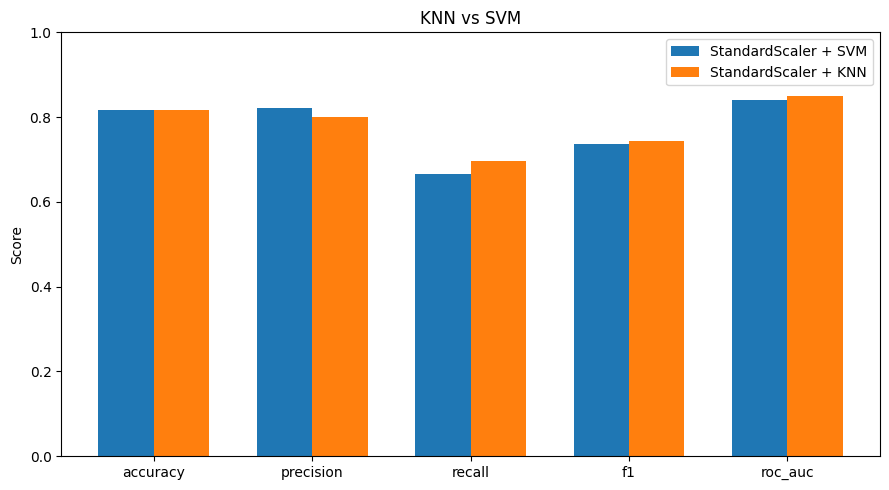

In [ ]:
# StandardScaler + KNN, MinMaxScaler + KNN 비교 - 시각화
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

svm_scores = [res_svm_standard[m] for m in metrics]
knn_scores = [res_knn_standard[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, svm_scores, width=width, label="StandardScaler + SVM")
plt.bar(x + width/2, knn_scores, width=width, label="StandardScaler + KNN")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("KNN vs SVM")
plt.legend()
plt.tight_layout()
plt.show()